In [50]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

Reverse colors

463


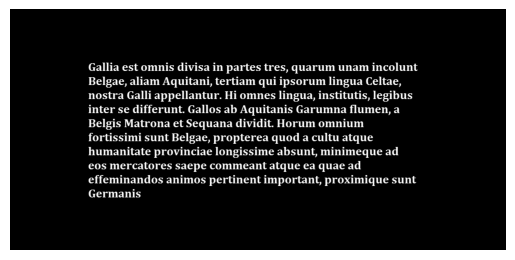

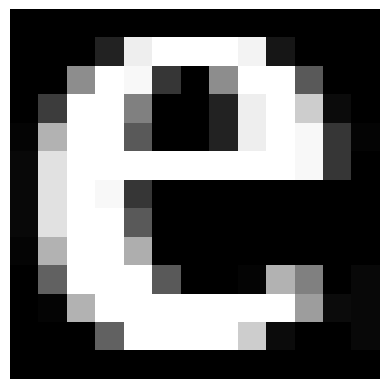

In [51]:
galia = cv2.imread("./galia.png")
galia = 255 - galia

h, w, _ = galia.shape

print(h)

e_letter = cv2.imread("./galia_e.png")
e_letter = 255 - e_letter

galia = cv2.cvtColor(galia, cv2.COLOR_BGR2GRAY)
e_letter = cv2.cvtColor(e_letter, cv2.COLOR_BGR2GRAY)

plt.imshow(galia, cmap='gray', vmin=0, vmax=255)
plt.axis("off")
plt.show()

plt.imshow(e_letter, cmap='gray', vmin=0, vmax=255)
plt.axis("off")
plt.show()

In [52]:
G = np.fft.fft2(galia, s=(h, w))
H = np.fft.fft2(np.rot90(e_letter, 2), s=(h, w))

C = np.real(np.fft.ifft2(G * H))

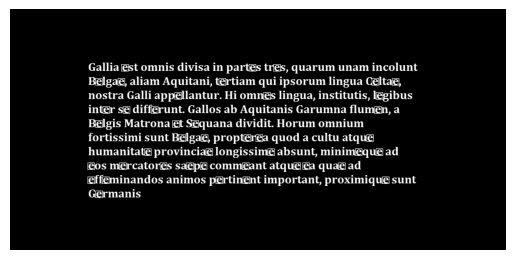

In [53]:
tsh = C.max() * 0.98

ys, xs = np.where(C > tsh)

h_t, w_t = e_letter.shape

galia_marked = galia.copy()

for x, y in zip(xs, ys):
    cv2.rectangle(galia_marked, (x, y), (x - w_t, y - h_t), 255, 1)

plt.imshow(galia_marked, cmap='gray', vmin=0, vmax=255)
plt.axis("off")
plt.show()